In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import torchvision.models as models
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torch.utils.data import Subset
from PIL import Image
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import pandas as pd
import os

# Define your paths again so this notebook knows where to look
train_dir = 'data/train'
test_dir = 'data/test'

import torch
print(f"Total GPUs: {torch.cuda.device_count()}")
for i in range(torch.cuda.device_count()):
    print(f"GPU {i}: {torch.cuda.get_device_name(i)}")

device = torch.device("cuda:0") # Use the index of the NVIDIA card
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Total GPUs: 1
GPU 0: NVIDIA GeForce RTX 3080 Laptop GPU
Using device: cuda:0


In [2]:
# --- 1. TRANSFORMATION DEFINITIONS ---
train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.RandomResizedCrop(48, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15), 
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.repeat(3, 1, 1)),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Test transform must be defined for the test_dataset
test_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.repeat(3, 1, 1)),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# --- 2. DATASET INITIALIZATION ---
# Load the full training folder
full_train_dataset = datasets.ImageFolder(root='data/train', transform=train_transform)

# Load the test folder (This prevents the NameError)
test_dataset = datasets.ImageFolder(root='data/test', transform=test_transform)

# --- 3. TRAIN/VAL SPLIT ---
train_idx, val_idx = train_test_split(
    range(len(full_train_dataset)),
    test_size=0.2,
    stratify=full_train_dataset.targets,
    random_state=42
)

train_data = Subset(full_train_dataset, train_idx)
val_data = Subset(full_train_dataset, val_idx)

# --- 4. DATALOADERS (Optimized for Laptop GPU) ---
# num_workers=2 and pin_memory=True help feed the NVIDIA GPU faster
train_loader = DataLoader(train_data, batch_size=64, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_data, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

print("Data Manager: All loaders (Train, Val, Test) are ready.")
print(f"Training images: {len(train_data)} | Validation images: {len(val_data)} | Test images: {len(test_dataset)}")

Data Manager: All loaders (Train, Val, Test) are ready.
Training images: 22967 | Validation images: 5742 | Test images: 7178


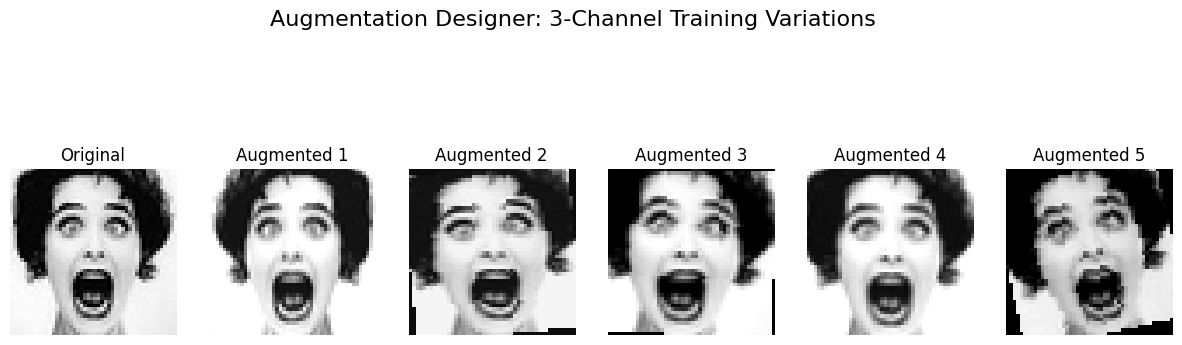

In [3]:
def visualize_augmentations(dataset, idx=0):
    plt.figure(figsize=(15, 5))
    
    # --- THE FIX FOR SUBSETS ---
    # If the dataset is a Subset, we need to find the real index in the original folder
    if isinstance(dataset, torch.utils.data.Subset):
        actual_idx = dataset.indices[idx]
        base_dataset = dataset.dataset
    else:
        actual_idx = idx
        base_dataset = dataset

    # 1. Show Original
    img_path, _ = base_dataset.samples[actual_idx]
    original_img = Image.open(img_path).convert('L')
    plt.subplot(1, 6, 1)
    plt.imshow(original_img, cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # 2. Show Augmented Versions
    for i in range(5):
        aug_tensor, _ = dataset[idx] # This still pulls the augmented version correctly
        
        # Convert from [3, 48, 48] to [48, 48, 3]
        aug_img = aug_tensor.numpy().transpose(1, 2, 0)
        
        # Undo the normalization for display
        aug_img = (aug_img * 0.5) + 0.5 
        aug_img = np.clip(aug_img, 0, 1) # Safety check for brightness/contrast
        
        plt.subplot(1, 6, i + 2)
        plt.imshow(aug_img) 
        plt.title(f"Augmented {i+1}")
        plt.axis('off')
    
    plt.suptitle("Augmentation Designer: 3-Channel Training Variations", fontsize=16)
    plt.show()

visualize_augmentations(train_data, idx=0)

In [4]:
model = models.resnet18(weights='DEFAULT')
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 7) 
model = model.to(device)

# --- THE TUNING TOOLS ---
# Label smoothing helps the model stay "open-minded" about similar emotions
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# Lower initial learning rate for better stability
optimizer = optim.Adam(model.parameters(), lr=0.0005)

# Scheduler: If accuracy doesn't improve for 2 epochs, cut LR by 90%
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.1, patience=2)

print("Model Architect: Fine-tuning mode engaged with Scheduler and Label Smoothing.")

Model Architect: Fine-tuning mode engaged with Scheduler and Label Smoothing.


In [9]:
# 1. Re-create the architecture (The Skeleton)
model = models.resnet18(weights=None)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 7)
model = model.to(device)

# 2. Re-create Optimizer and Scheduler (The Muscle)
optimizer = optim.Adam(model.parameters(), lr=0.0005)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.1, patience=2)

# 3. Load the Checkpoint
checkpoint = torch.load('emotion_checkpoint.pth')

# 4. Restore everything
model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
start_epoch = checkpoint['epoch'] + 1
history = checkpoint['history']

print(f"Resuming from Epoch {start_epoch} with Val Acc: {checkpoint['val_acc']:.4f}")

Resuming from Epoch 20 with Val Acc: 0.6308


In [10]:
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
epochs = 20 # Increased epochs to give the scheduler time to work

for epoch in range(epochs):
    model.train()
    train_loss, train_correct = 0, 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        train_correct += torch.sum(preds == labels.data)
    
    model.eval()
    val_loss, val_correct = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            val_correct += torch.sum(preds == labels.data)
            
    train_loss /= len(train_data)
    train_acc = train_correct.double() / len(train_data)
    val_loss /= len(val_data)
    val_acc = val_correct.double() / len(val_data)
    
    # --- IMPORTANT: UPDATE THE SCHEDULER ---
    scheduler.step(val_acc)
    current_lr = optimizer.param_groups[0]['lr']
    
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc.item())
    history['val_acc'].append(val_acc.item())
    
    print(f'Epoch {epoch+1}/{epochs}: Train Loss: {train_loss:.4f} | Val Acc: {val_acc:.4f} | LR: {current_lr:.6f}')

# Save progress immediately after training
torch.save(model.state_dict(), 'emotion_model_optimized.pth')

Epoch 1/20: Train Loss: 0.9257 | Val Acc: 0.6264 | LR: 0.000000
Epoch 2/20: Train Loss: 0.9260 | Val Acc: 0.6331 | LR: 0.000000
Epoch 3/20: Train Loss: 0.9242 | Val Acc: 0.6284 | LR: 0.000000
Epoch 4/20: Train Loss: 0.9312 | Val Acc: 0.6216 | LR: 0.000000
Epoch 5/20: Train Loss: 0.9304 | Val Acc: 0.6296 | LR: 0.000000
Epoch 6/20: Train Loss: 0.9257 | Val Acc: 0.6299 | LR: 0.000000
Epoch 7/20: Train Loss: 0.9222 | Val Acc: 0.6310 | LR: 0.000000
Epoch 8/20: Train Loss: 0.9313 | Val Acc: 0.6240 | LR: 0.000000
Epoch 9/20: Train Loss: 0.9319 | Val Acc: 0.6329 | LR: 0.000000
Epoch 10/20: Train Loss: 0.9228 | Val Acc: 0.6233 | LR: 0.000000
Epoch 11/20: Train Loss: 0.9269 | Val Acc: 0.6313 | LR: 0.000000
Epoch 12/20: Train Loss: 0.9261 | Val Acc: 0.6285 | LR: 0.000000
Epoch 13/20: Train Loss: 0.9296 | Val Acc: 0.6243 | LR: 0.000000
Epoch 14/20: Train Loss: 0.9259 | Val Acc: 0.6217 | LR: 0.000000
Epoch 15/20: Train Loss: 0.9298 | Val Acc: 0.6287 | LR: 0.000000
Epoch 16/20: Train Loss: 0.9314 | 

In [11]:
checkpoint = {
    'epoch': epoch,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'scheduler_state_dict': scheduler.state_dict(), # Save this too!
    'history': history,
    'val_acc': val_acc
}

torch.save(checkpoint, 'emotion_checkpoint.pth')
print("Full training state saved.")

Full training state saved.


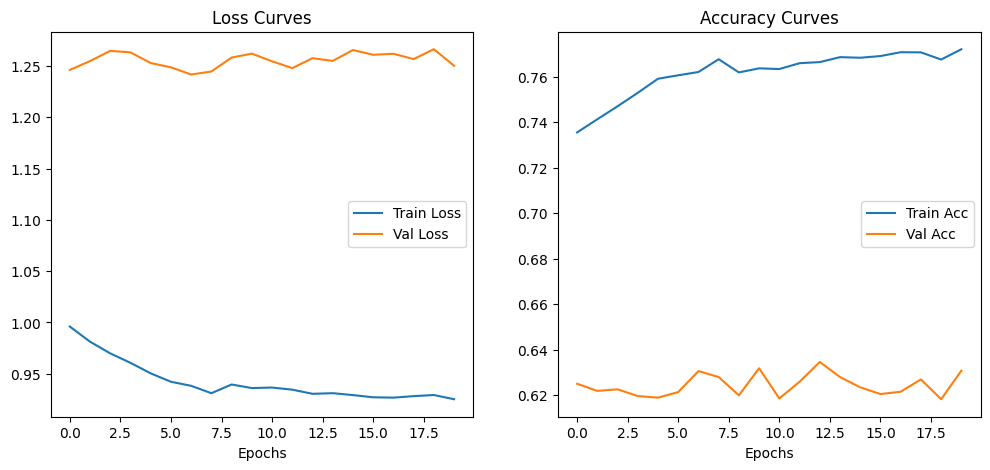

In [8]:
def plot_curves(history):
    plt.figure(figsize=(12, 5))
    
    # Plot Loss
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Val Loss')
    plt.title('Loss Curves')
    plt.xlabel('Epochs')
    plt.legend()
    
    # Plot Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(history['train_acc'], label='Train Acc')
    plt.plot(history['val_acc'], label='Val Acc')
    plt.title('Accuracy Curves')
    plt.xlabel('Epochs')
    plt.legend()
    
    plt.show()

plot_curves(history)

In [12]:
# 1. Put model in evaluation mode (turns off Dropout and Batch Normalization)
model.eval()

test_correct = 0
test_total = 0

# 2. Disable gradient calculation (saves memory and speeds up the process)
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        
        # Forward pass
        outputs = model(images)
        
        # Get predictions
        _, preds = torch.max(outputs, 1)
        
        # Update counts
        test_total += labels.size(0)
        test_correct += (preds == labels).sum().item()

# 3. Calculate and print final accuracy
final_test_acc = 100 * test_correct / test_total
print(f"Final Test Accuracy: {final_test_acc:.2f}%")

Final Test Accuracy: 65.34%


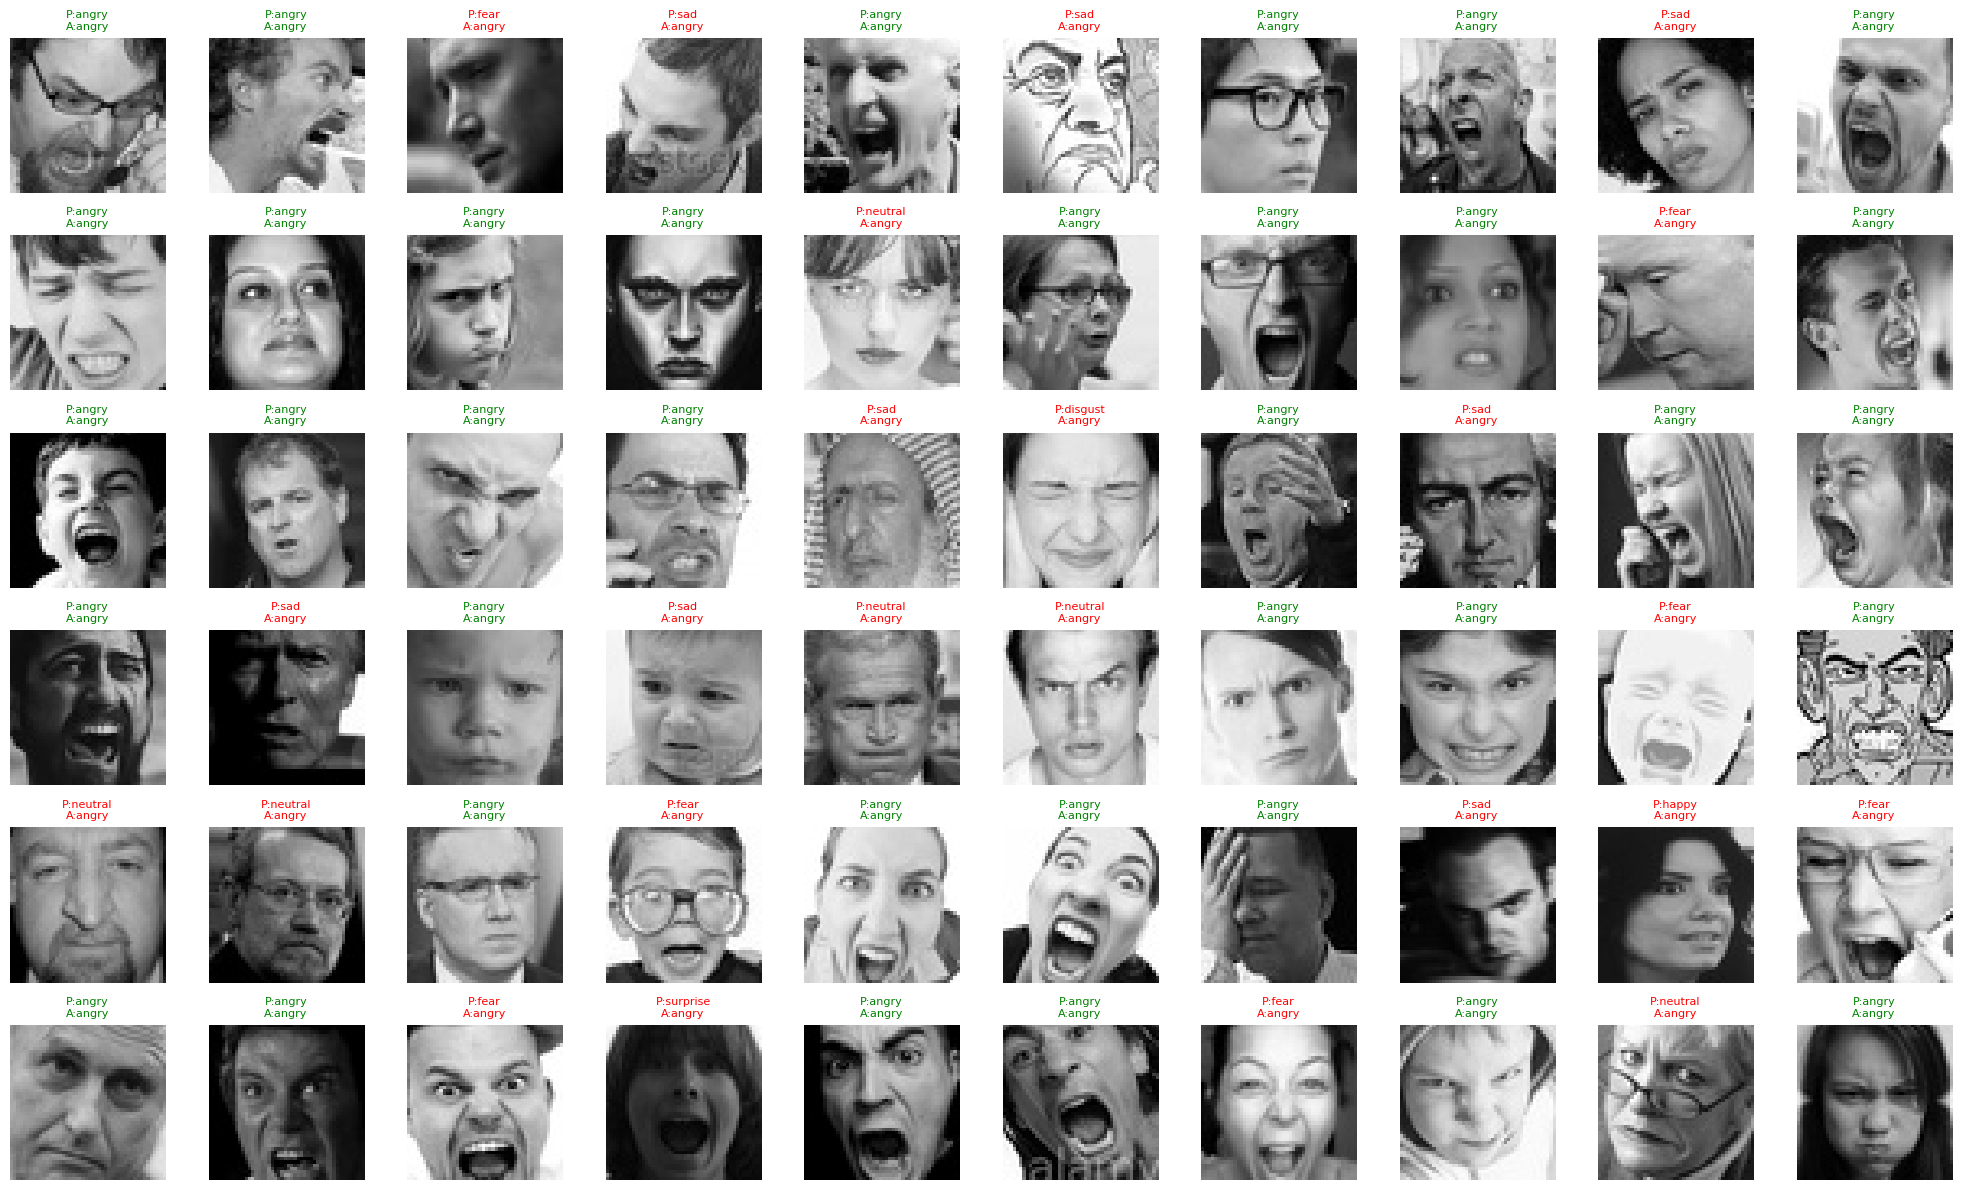

In [14]:
def visualize_test_gallery(model, dataset, num_images=60, cols=10):
    model.eval()
    rows = num_images // cols + (1 if num_images % cols != 0 else 0)
    plt.figure(figsize=(20, 2 * rows)) # Wide figure to fit 10 columns
    
    # Get a fixed slice or random sample from the test set
    indices = range(num_images) # Shows the first 60 images
    
    class_names = dataset.classes
    
    with torch.no_grad():
        for i, idx in enumerate(indices):
            image_tensor, true_label = dataset[idx]
            
            # Predict
            input_tensor = image_tensor.unsqueeze(0).to(device)
            outputs = model(input_tensor)
            _, pred_idx = torch.max(outputs, 1)
            
            # Prepare image
            img_display = image_tensor.permute(1, 2, 0).cpu().numpy()
            img_display = (img_display * 0.5) + 0.5
            img_display = np.clip(img_display, 0, 1)
            
            plt.subplot(rows, cols, i + 1)
            plt.imshow(img_display)
            
            # Color coding
            is_correct = pred_idx.item() == true_label
            color = 'green' if is_correct else 'red'
            
            # Simplified title for space: Predicted (Actual)
            plt.title(f"P:{class_names[pred_idx]}\nA:{class_names[true_label]}", 
                      color=color, fontsize=8)
            plt.axis('off')
            
    plt.tight_layout()
    plt.show()

# Run the gallery view
visualize_test_gallery(model, test_dataset, num_images=60)

--- Per-Emotion Performance Report ---
              precision    recall  f1-score   support

       angry       0.56      0.60      0.58       958
     disgust       0.73      0.49      0.58       111
        fear       0.53      0.47      0.50      1024
       happy       0.86      0.85      0.85      1774
     neutral       0.58      0.66      0.62      1233
         sad       0.54      0.49      0.51      1247
    surprise       0.74      0.77      0.76       831

    accuracy                           0.65      7178
   macro avg       0.65      0.62      0.63      7178
weighted avg       0.65      0.65      0.65      7178



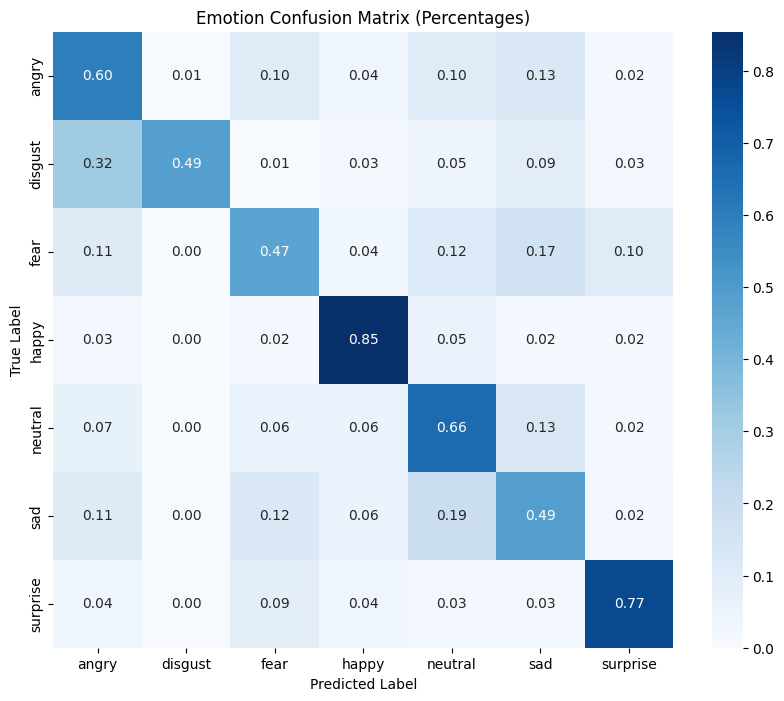

In [ ]:
def run_full_evaluation(model, loader, dataset):
    model.eval()
    all_preds = []
    all_labels = []
    
    # 1. Collect all predictions
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    class_names = dataset.classes
    
    # 2. Per-Emotion Accuracy (Classification Report)
    print("--- Per-Emotion Performance Report ---")
    print(classification_report(all_labels, all_preds, target_names=class_names))
    
    # 3. Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    
    # Normalize the matrix to see percentages instead of raw counts
    cm_perc = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    sns.heatmap(cm_perc, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    
    plt.title('Emotion Confusion Matrix (Percentages)')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

# Run it
run_full_evaluation(model, test_loader, test_dataset)